In [1]:
import os
import glob
import json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Data analysis
In this document I will go further in depth on my data quality.

In [2]:
def load_yolo_labels(label_dir):
    data = []

    label_files = glob.glob(os.path.join(label_dir, '*.txt'))

    for file in label_files:
        image_id = os.path.basename(file).split('.')[0]

        with open(file, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = list(map(float, line.strip().split()))
            if len(parts) != 5:
                continue # Skip lines that don't have exactly 5 parts, since yolo labels should have 5 parts: class_id, x_center, y_center, width, height

            cls, x, y, w, h = parts

            data.append({
                "image_id": image_id,
                "class": int(cls),
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "area": w * h
            })

    return data

In [3]:
def group_by_image(data):
    grouped = defaultdict(list)
    
    for data_point in data:
        grouped[data_point['image_id']].append(data_point)

    return dict(grouped)

grouped_labels = group_by_image(load_yolo_labels(r"Data\DSYD raw data\DeepSpaceYoloDataset\labels"))

with open('grouped_labels.json', 'w') as f:
    json.dump(grouped_labels, f, indent=4)

In [4]:
data = json.load(open('grouped_labels.json'))

In [5]:
from collections import defaultdict
import numpy as np

def data_stats(data):
    widths = []
    heights = []
    areas = []

    objects_per_image = {}

    for image_id, objects in data.items():
        objects_per_image[image_id] = len(objects)

        for obj in objects:
            widths.append(obj['w'])
            heights.append(obj['h'])
            areas.append(obj['area'])

    print("Dataset statistics:")
    print(f"Total objects: {len(widths)}")
    print(f"Total images with objects: {len(objects_per_image)}")

    print('\nBounding box stats:')
    print(f"Width  - mean: {np.mean(widths):.4f}, min: {np.min(widths):.4f}, max: {np.max(widths):.4f}")
    print(f"Height - mean: {np.mean(heights):.4f}, min: {np.min(heights):.4f}, max: {np.max(heights):.4f}")
    print(f"Area   - mean: {np.mean(areas):.4f}, min: {np.min(areas):.6f}, max: {np.max(areas):.4f}")

    print("\nObjects per image:")
    print(f"Mean: {np.mean(list(objects_per_image.values())):.2f}")
    print(f"Max: {np.max(list(objects_per_image.values()))}")

data_stats(data)

Dataset statistics:
Total objects: 6095
Total images with objects: 4696

Bounding box stats:
Width  - mean: 0.3020, min: 0.0033, max: 1.0000
Height - mean: 0.2988, min: 0.0049, max: 1.0000
Area   - mean: 0.1711, min: 0.000097, max: 1.0000

Objects per image:
Mean: 1.30
Max: 5


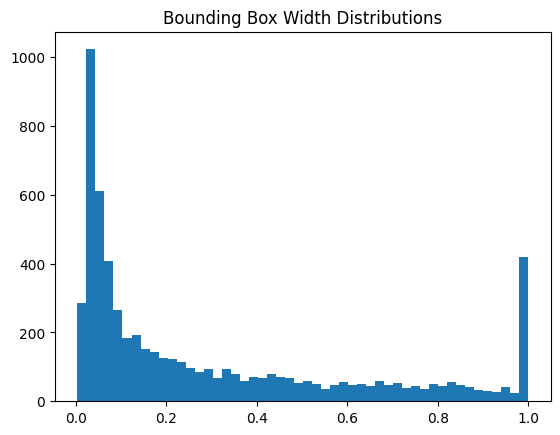

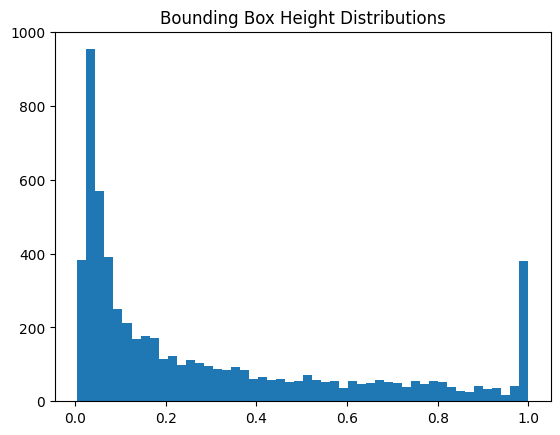

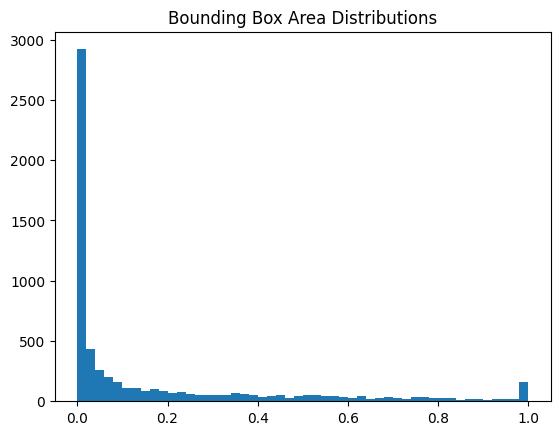

In [6]:
def plot_distributions(data):
    widths = []
    heights = []
    areas = []

    objects_per_image = {}

    for image_id, objects in data.items():
        objects_per_image[image_id] = len(objects)

        for obj in objects:
            widths.append(obj['w'])
            heights.append(obj['h'])
            areas.append(obj['area'])

    plt.figure()
    plt.hist(widths, bins=50)
    plt.title("Bounding Box Width Distributions")
    plt.show()

    plt.figure()
    plt.hist(heights, bins=50)
    plt.title("Bounding Box Height Distributions")
    plt.show()

    plt.figure()
    plt.hist(areas, bins=50)
    plt.title("Bounding Box Area Distributions")
    plt.show()

plot_distributions(data)

In [ ]:
def find_suspicious_labels(data,
                           min_area=0.0005,
                           max_size=0.9):

    issues = []

    for image_id, objects in data.items():
        for obj in objects:
            problems = []

            if obj["w"] <= 0 or obj["h"] <= 0:
                problems.append("zero_or_negative_size")

            if obj["w"] > max_size or obj["h"] > max_size:
                problems.append("too_large")

            if obj["area"] < min_area:
                problems.append("too_small")

            if not (0 <= obj["x"] <= 1 and 0 <= obj["y"] <= 1):
                problems.append("center_out_of_bounds")

            if problems:
                issues.append({
                    "image_id": image_id,
                    "problems": problems
                })

    print(f"Found {len(issues)} suspicious annotations")
    return issues

suspicious_labels = find_suspicious_labels(data, min_area=0.001, max_size=0.95)
suspicious_labels

Found 3760 suspicious annotations


[{'image_id': '1', 'problems': ['too_small']},
 {'image_id': '1', 'problems': ['too_small']},
 {'image_id': '10', 'problems': ['too_small']},
 {'image_id': '1000', 'problems': ['too_large']},
 {'image_id': '1002', 'problems': ['too_large']},
 {'image_id': '1006', 'problems': ['too_large']},
 {'image_id': '1011', 'problems': ['too_small']},
 {'image_id': '1013', 'problems': ['too_large']},
 {'image_id': '1020', 'problems': ['too_large']},
 {'image_id': '1021', 'problems': ['too_large']},
 {'image_id': '1023', 'problems': ['too_large']},
 {'image_id': '1027', 'problems': ['too_large']},
 {'image_id': '1031', 'problems': ['too_large']},
 {'image_id': '1032', 'problems': ['too_large']},
 {'image_id': '1033', 'problems': ['too_large']},
 {'image_id': '1034', 'problems': ['too_large']},
 {'image_id': '1036', 'problems': ['too_large']},
 {'image_id': '1037', 'problems': ['too_small']},
 {'image_id': '1038', 'problems': ['too_large']},
 {'image_id': '1039', 'problems': ['too_large']},
 {'image

In [16]:
def show_image_with_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    print(f"Image shape: {img.shape}")
    h_img, w_img, _ = img.shape

    with open(label_path, "r") as f:
        lines = f.readlines()
        print(f"Labels for {image_path}:")

    for line in lines:
        cls, x, y, w, h = map(float, line.strip().split())

        # Convert YOLO → pixel coords
        x1 = int((x - w/2) * w_img)
        y1 = int((y - h/2) * h_img)
        x2 = int((x + w/2) * w_img)
        y2 = int((y + h/2) * h_img)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    
    cv2.imshow("Image", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

show_image_with_boxes(
    r"Data\DSYD raw data\DeepSpaceYoloDataset\images\1000.jpg",
    r"Data\DSYD raw data\DeepSpaceYoloDataset\labels\1000.txt"
)

Image shape: (608, 608, 3)
Labels for Data\DSYD raw data\DeepSpaceYoloDataset\images\1000.jpg:
